# Fire Season Timing Graphs - Turkey Ecoregion Scale 

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
from scipy import stats

# Load master CSV
output_dir = 'outputs/turkey_ecoregions'
master_df  = pd.read_csv(f'{output_dir}/master_turkey.csv')

print(f'Loaded {len(master_df)} rows')
print(f'Ecoregions: {master_df["eco_name"].nunique()}')
print(f'Years: {master_df["year"].min()} – {master_df["year"].max()}')
print()
print(master_df.head())

Loaded 304 rows
Ecoregions: 14
Years: 2003 – 2025

   eco_id                                       eco_name  year  onset_doy  \
0     786  Anatolian conifer and deciduous mixed forests  2003         94   
1     786  Anatolian conifer and deciduous mixed forests  2004         81   
2     786  Anatolian conifer and deciduous mixed forests  2005         74   
3     786  Anatolian conifer and deciduous mixed forests  2006         86   
4     786  Anatolian conifer and deciduous mixed forests  2007         82   

   peak_doy  end_doy  season_length  n_detections  
0       207      295            202           878  
1       222      308            228           971  
2       196      312            239           804  
3       192      281            196           707  
4       206      283            202           969  


In [21]:
# FILTER — EXCLUDE ECOREGIONS WITH FEWER THAN 20 VALID YEARS ---------------

MIN_VALID_YEARS = 20

# Count how many years are present per ecoregion
# (missing years were never written to the CSV, so absence = failed year)
valid_year_counts = (
    master_df
    .groupby('eco_name')['year']
    .count()
    .rename('n_valid_years')
)

# Identify passing and excluded ecoregions
passing  = valid_year_counts[valid_year_counts >= MIN_VALID_YEARS].index
excluded = valid_year_counts[valid_year_counts <  MIN_VALID_YEARS]

# Report
if len(excluded) > 0:
    print(f'Excluded {len(excluded)} ecoregion(s) with < {MIN_VALID_YEARS} valid years:')
    for name, n in excluded.items():
        print(f'  {name}: {n} valid years')
else:
    print('No ecoregions excluded.')

# Apply — all downstream cells use this filtered master_df
master_df = master_df[master_df['eco_name'].isin(passing)].copy()

print(f'\nRetained: {master_df["eco_name"].nunique()} ecoregions')
print(f'Rows:     {len(master_df)}')

Excluded 1 ecoregion(s) with < 20 valid years:
  Caucasus mixed forests: 5 valid years

Retained: 13 ecoregions
Rows:     299


In [22]:
graphs_dir = 'outputs/turkey_ecoregions/graphs'
os.makedirs(graphs_dir, exist_ok=True)

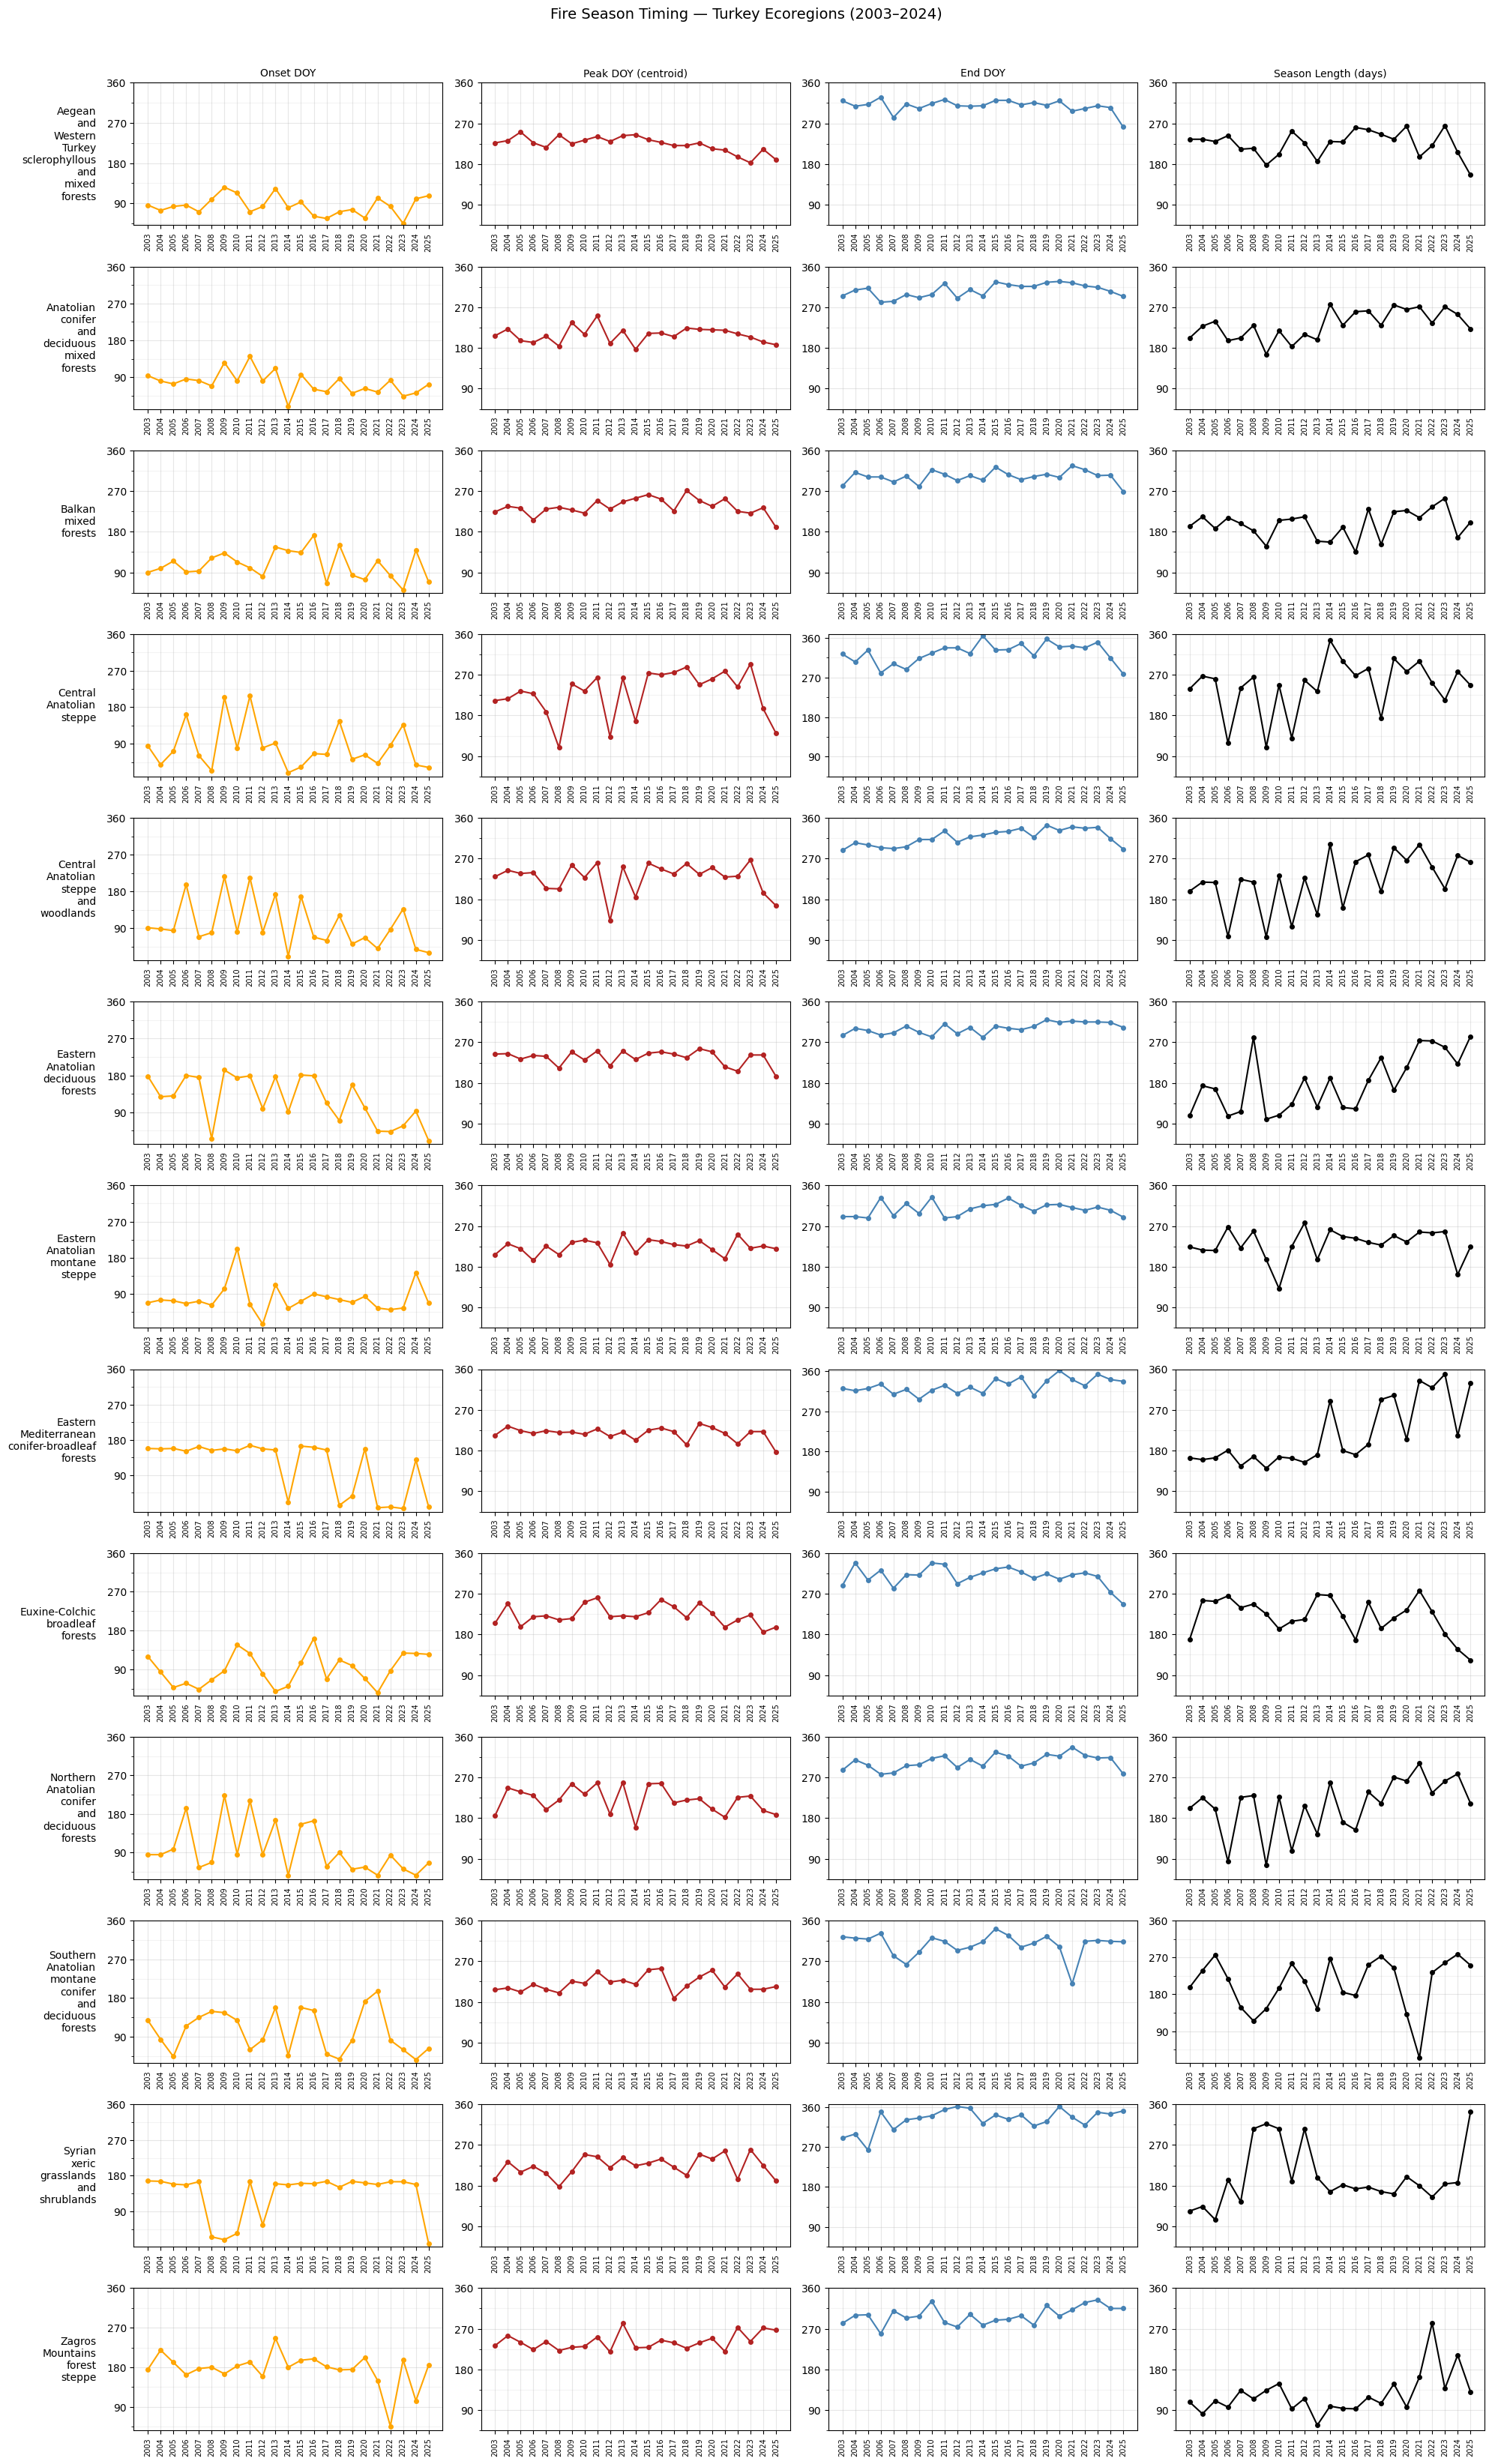

In [27]:
n_ecos    = master_df['eco_name'].nunique()
eco_names = master_df['eco_name'].unique()

fig, axes = plt.subplots(n_ecos, 4, figsize=(20, n_ecos * 2.5))
fig.suptitle('Fire Season Timing — Turkey Ecoregions (2003–2024)',
             fontsize=14, y=1.01)

metrics = [
    ('onset_doy',     'Onset DOY',            'orange'),
    ('peak_doy',      'Peak DOY (centroid)',   'firebrick'),
    ('end_doy',       'End DOY',              'steelblue'),
    ('season_length', 'Season Length (days)', 'black'),
]

for row_idx, eco_name in enumerate(sorted(eco_names)):
    eco_df = master_df[master_df['eco_name'] == eco_name].sort_values('year')

    for col_idx, (metric, title, color) in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        ax.plot(eco_df['year'], eco_df[metric],
                marker='o', color=color, linewidth=1.5, markersize=4)
        ax.set_yticks([90, 180, 270, 360], minor=False)
        ax.set_yticks([45, 135, 225, 315], minor=True)
        ax.yaxis.set_minor_formatter(plt.NullFormatter())
        ax.grid(True, alpha=0.3)
        ax.grid(True, which="minor", alpha=0.15)
        ax.set_xticks(eco_df['year'])
        ax.tick_params(axis='x', rotation=90, labelsize=7)

        if row_idx == 0:
            ax.set_title(title, fontsize=10)
        if col_idx == 0:
            ax.set_ylabel(eco_name.replace(' ', '\n'), fontsize=10, rotation=0, labelpad=10)
            ax.yaxis.label.set_ha('right')
            ax.yaxis.label.set_va('center')

plt.tight_layout()
plt.savefig(f'{graphs_dir}/graph_01_timing_per_ecoregion.png',
            dpi=150, bbox_inches='tight')
plt.show()

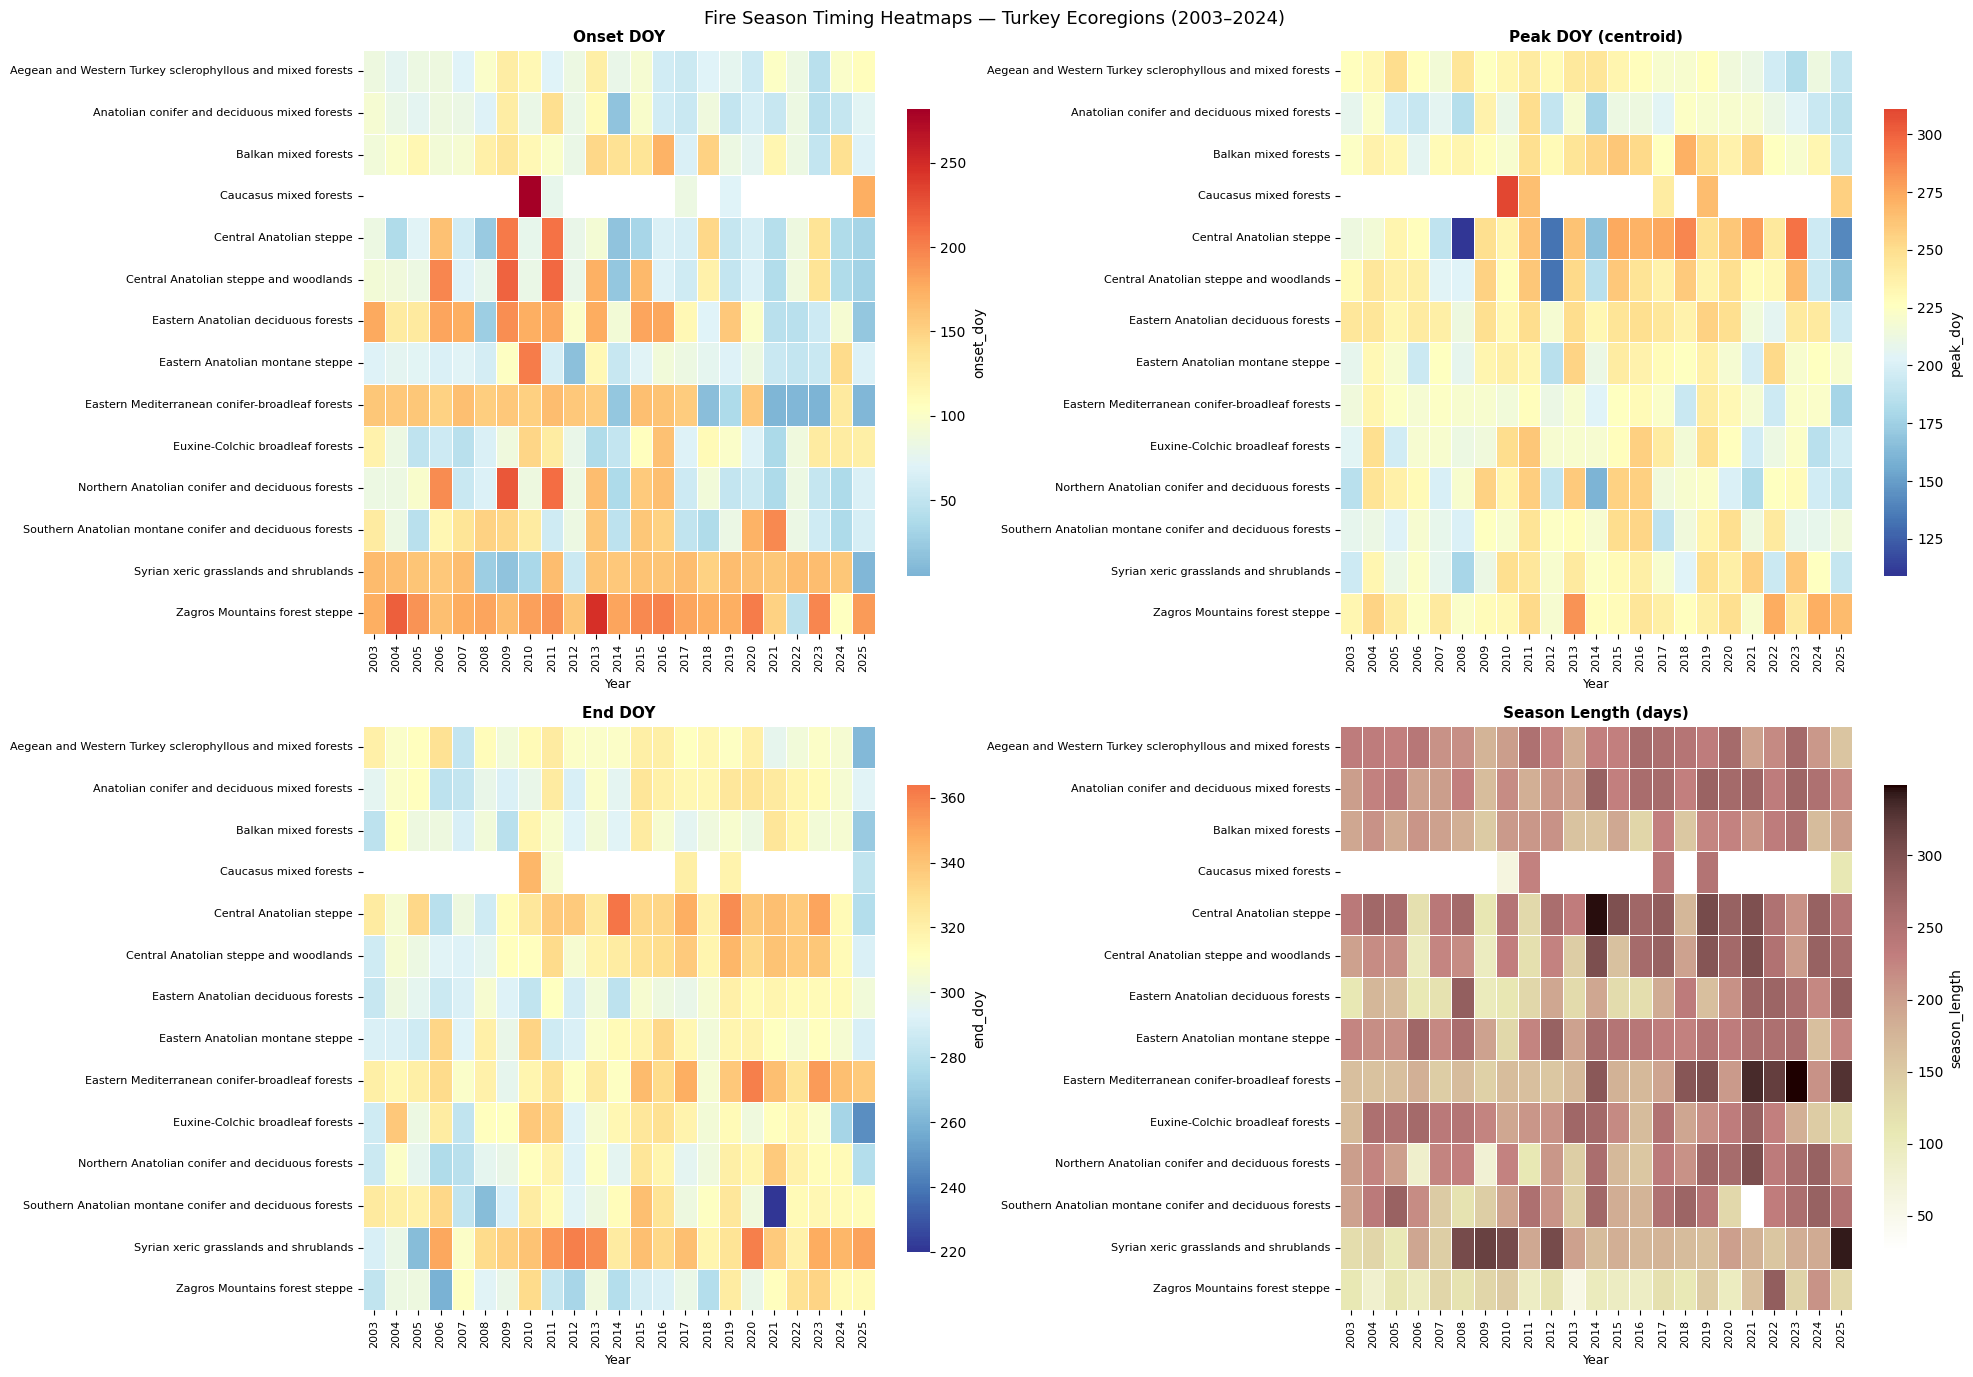

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Fire Season Timing Heatmaps — Turkey Ecoregions (2003–2024)', fontsize=13)

metrics = [
    ('onset_doy',     'Onset DOY',            'RdYlBu_r'),  # blue=early, red=late
    ('peak_doy',      'Peak DOY (centroid)',   'RdYlBu_r'),
    ('end_doy',       'End DOY',              'RdYlBu_r'),
    ('season_length', 'Season Length (days)', 'pink_r'),    # red=short, green=long
]

for ax, (metric, title, cmap) in zip(axes.flatten(), metrics):
    pivot = master_df.pivot(index='eco_name', columns='year', values=metric)

    # Only center diverging colormaps (onset, peak, end) — not season_length
    center = np.nanmean(pivot.values) if metric != 'season_length' else None
    
    sns.heatmap(
        pivot,
        ax         = ax,
        cmap       = cmap,
        center     = center,
        linewidths = 0.4,
        linecolor  = 'white',
        annot      = False,
        cbar_kws   = {'shrink': 0.8, 'label': metric}
    )

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=8, rotation=90)

plt.tight_layout()
plt.savefig(f'{graphs_dir}/graph_02_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

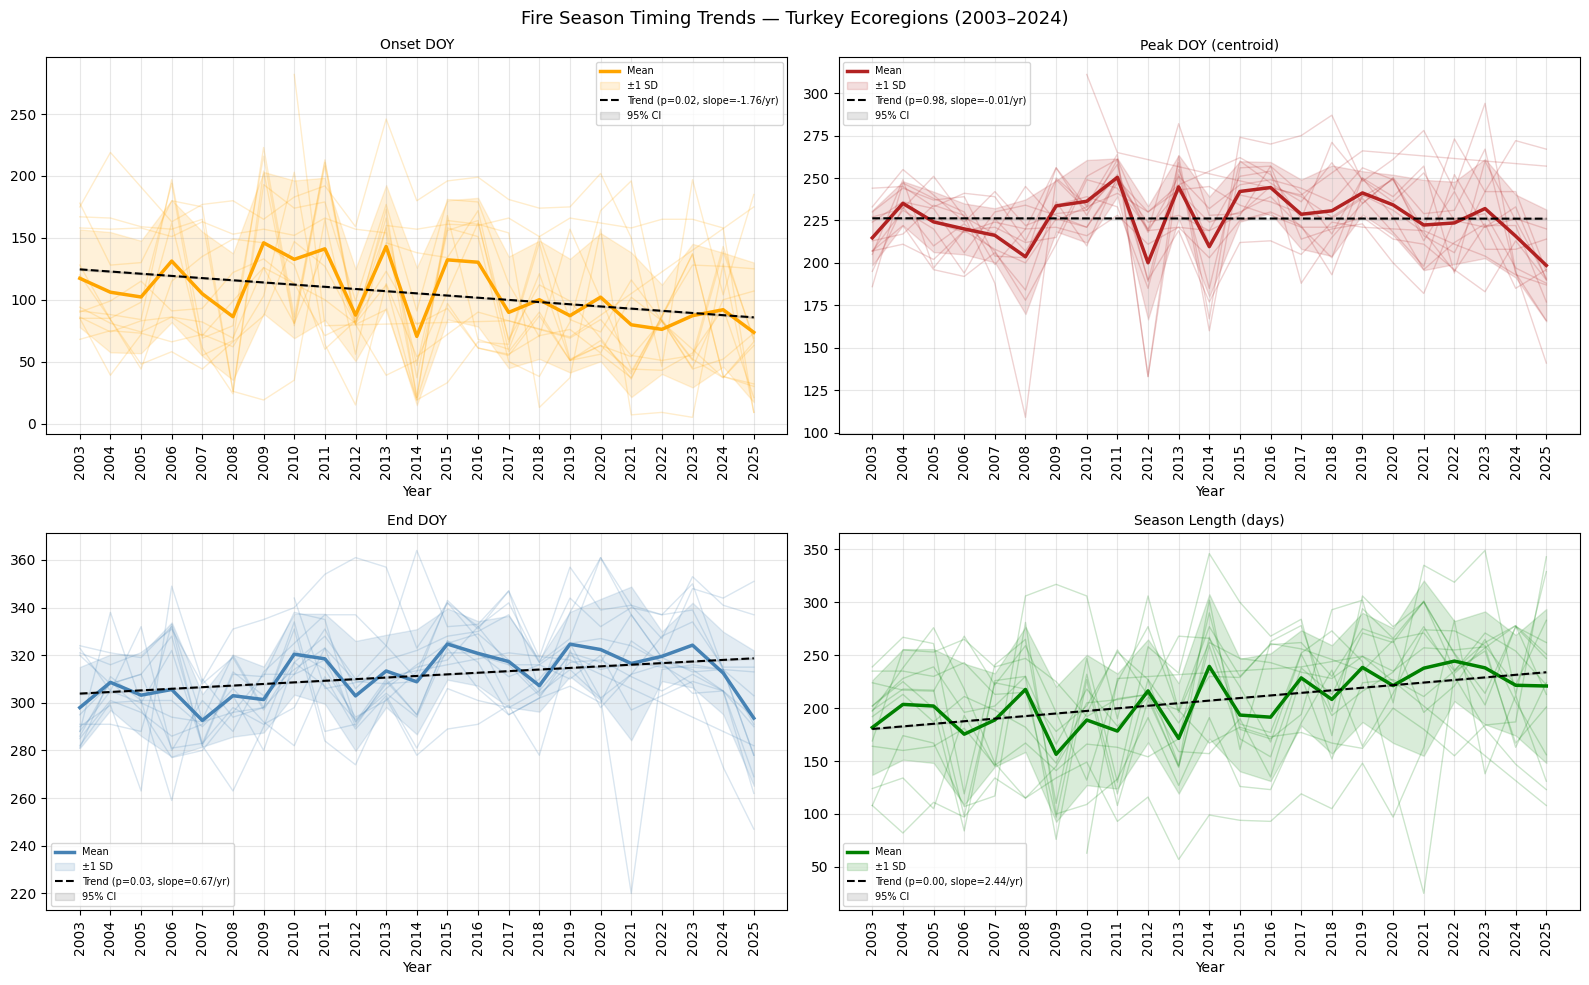

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Fire Season Timing Trends — Turkey Ecoregions (2003–2024)', fontsize=13)

metrics = [
    ('onset_doy',     'Onset DOY',            'orange'),
    ('peak_doy',      'Peak DOY (centroid)',   'firebrick'),
    ('end_doy',       'End DOY',              'steelblue'),
    ('season_length', 'Season Length (days)', 'green'),
]

for ax, (metric, title, color) in zip(axes.flatten(), metrics):
    # Plot each ecoregion as a faint line
    for eco_name, group in master_df.groupby('eco_name'):
        ax.plot(group['year'], group[metric],
                color=color, alpha=0.2, linewidth=1)

    # Plot the cross-ecoregion mean per year as a bold line
    yearly_mean = master_df.groupby('year')[metric].mean()
    yearly_std  = master_df.groupby('year')[metric].std()
    years       = yearly_mean.index

    ax.plot(years, yearly_mean, color=color, linewidth=2.5, label='Mean')
    ax.fill_between(years,
                    yearly_mean - yearly_std,
                    yearly_mean + yearly_std,
                    color=color, alpha=0.15, label='±1 SD')

    # Fit and plot overall trend line
    slope, intercept, r, p, se = stats.linregress(years, yearly_mean)
    trend = np.array([slope * y + intercept for y in years])

    # 95% confidence interval around the trend line
    # se is the standard error of the slope
    n        = len(years)
    t_crit   = stats.t.ppf(0.975, df=n - 2)  # 95% two-tailed critical value
    x_mean   = np.mean(years)
    ss_x     = np.sum((np.array(years) - x_mean) ** 2)
    ci       = t_crit * se * np.sqrt(1/n + (np.array(years) - x_mean)**2 / ss_x)

    ax.plot(years, trend, color='black', linewidth=1.5,
        linestyle='--', label=f'Trend (p={p:.2f}, slope={slope:.2f}/yr)')
    ax.fill_between(years, trend - ci, trend + ci,
                color='black', alpha=0.1, label='95% CI')

    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Year')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(years)
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig(f'{graphs_dir}/graph_03_trends.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import json
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import shape

# Load pre-saved clipped geometries — no GEE needed
with open('outputs/turkey_ecoregions/eco_geometries.json') as f:
    geo_records = json.load(f)

eco_records = [
    {'eco_id': r['eco_id'], 'eco_name': r['eco_name'], 'geometry': shape(r['geometry'])}
    for r in geo_records
]

print(f'Loaded {len(eco_records)} clipped ecoregion geometries.')

Loaded 14 clipped ecoregion geometries.


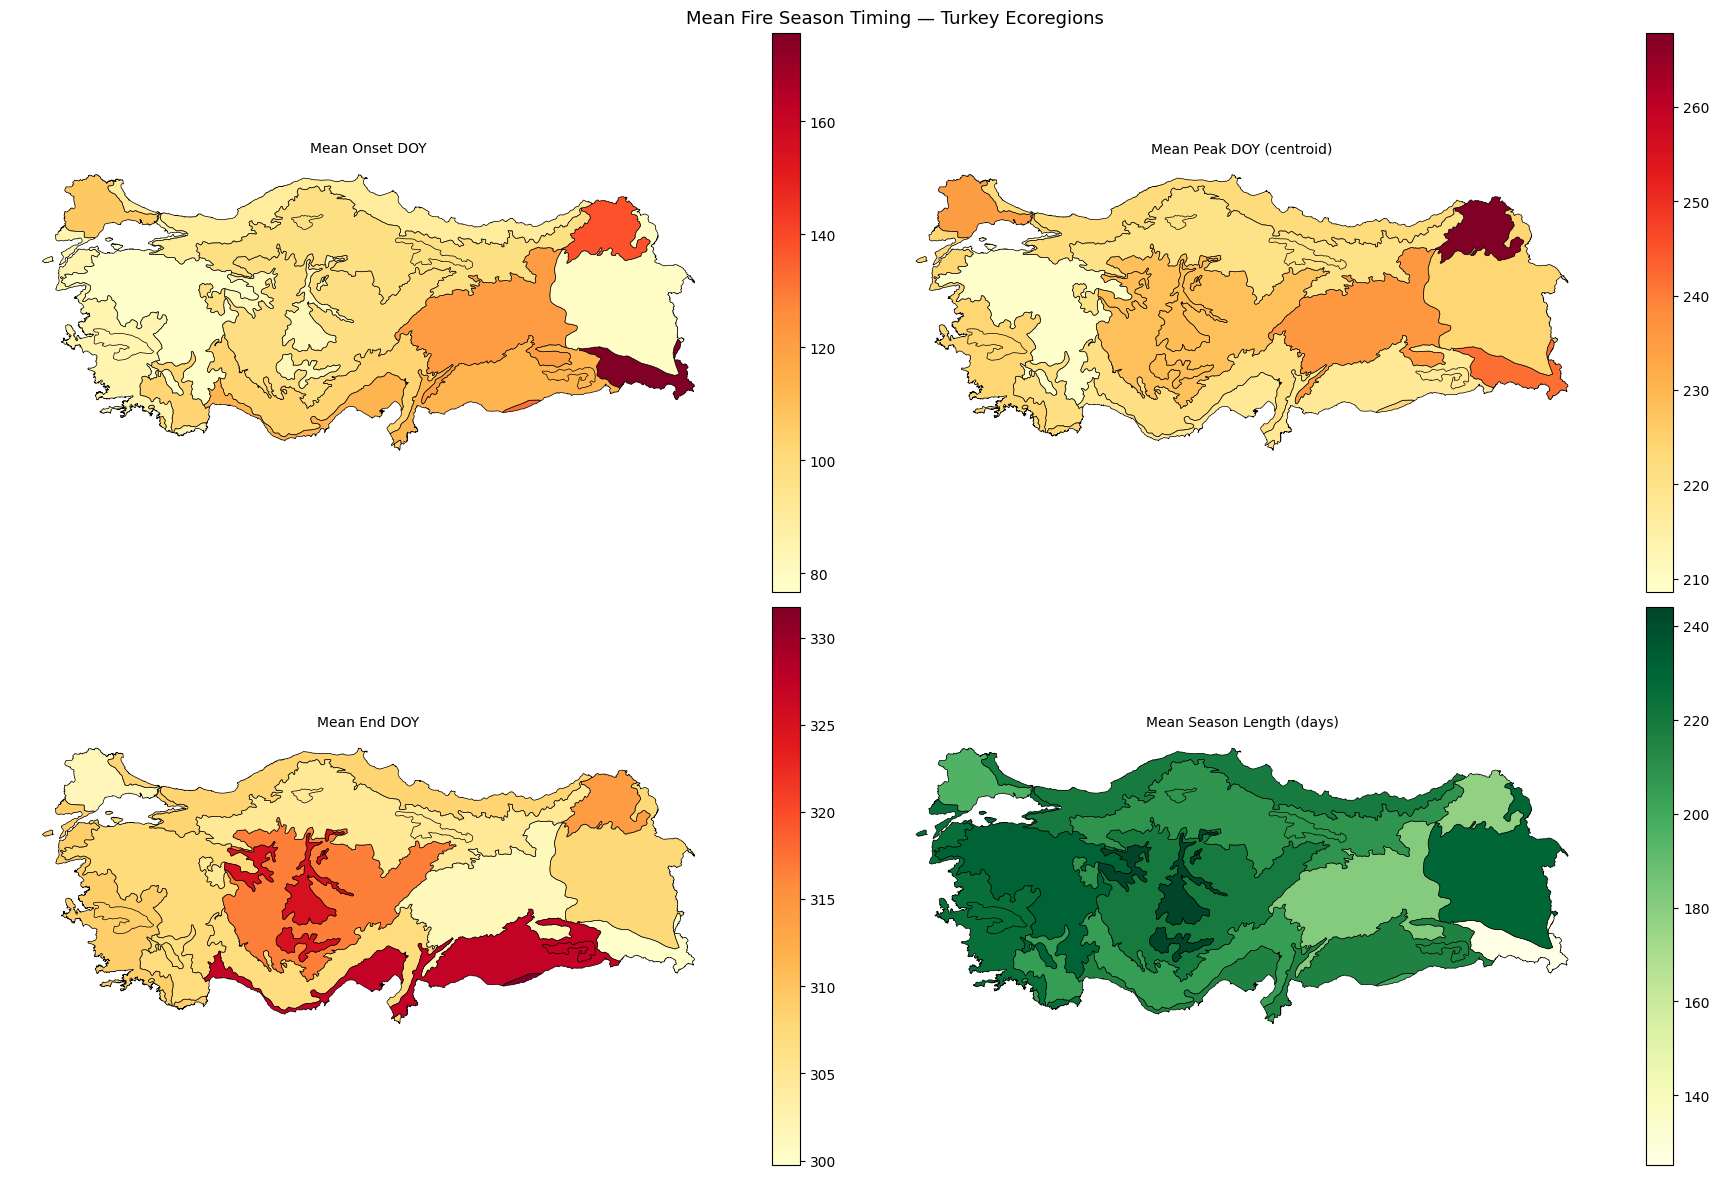

In [17]:
# Load master CSV
master_df = pd.read_csv('outputs/turkey_ecoregions/master_turkey.csv')

# Mean metrics per ecoregion across all years
mean_metrics = master_df.groupby('eco_name')[
    ['onset_doy', 'peak_doy', 'end_doy', 'season_length']
].mean().reset_index()

# Build GeoDataFrame from clipped geometries and merge metrics
eco_gdf    = gpd.GeoDataFrame(eco_records, crs='EPSG:4326')
eco_merged = eco_gdf.merge(mean_metrics, on='eco_name')

# Plot
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Mean Fire Season Timing — Turkey Ecoregions', fontsize=13)

metrics = [
    ('onset_doy',     'Mean Onset DOY',           'YlOrRd'),
    ('peak_doy',      'Mean Peak DOY (centroid)',  'YlOrRd'),
    ('end_doy',       'Mean End DOY',              'YlOrRd'),
    ('season_length', 'Mean Season Length (days)', 'YlGn'),
]

for ax, (metric, title, cmap) in zip(axes.flatten(), metrics):
    eco_merged.plot(column=metric, ax=ax, cmap=cmap,
                    legend=True, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()

plt.tight_layout()
plt.savefig(f'{graphs_dir}/graph_04_map.png', dpi=150, bbox_inches='tight')
plt.show()

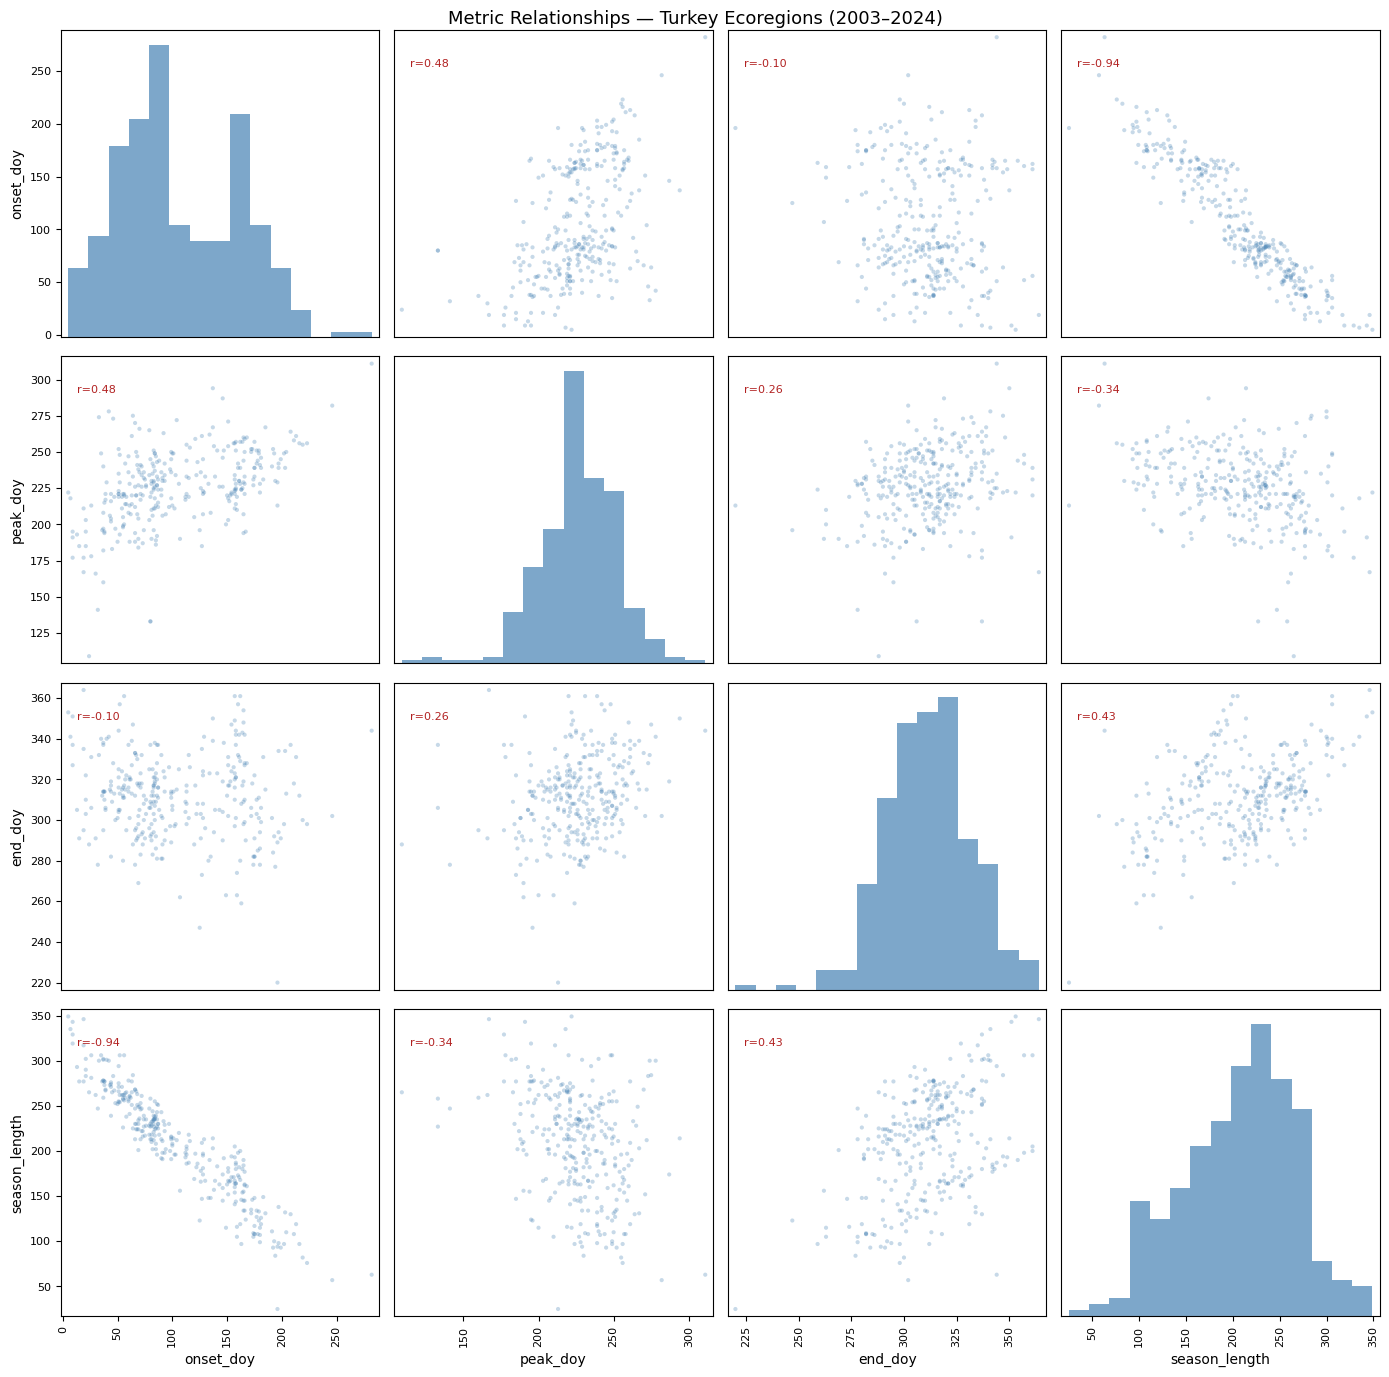

In [16]:
from pandas.plotting import scatter_matrix

cols = ['onset_doy', 'peak_doy', 'end_doy', 'season_length']

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Metric Relationships — Turkey Ecoregions (2003–2024)', fontsize=13)

scatter_matrix(
    master_df[cols],
    ax           = axes,
    alpha        = 0.3,
    diagonal     = 'hist',
    color        = 'steelblue',
    hist_kwds    = {'bins': 15, 'color': 'steelblue', 'alpha': 0.7}
)

# Add correlation values to each panel
for i, col1 in enumerate(cols):
    for j, col2 in enumerate(cols):
        if i != j:
            r, p = stats.pearsonr(
                master_df[col1].dropna(),
                master_df[col2].dropna()
            )
            axes[i, j].annotate(f'r={r:.2f}', xy=(0.05, 0.88),
                                 xycoords='axes fraction', fontsize=8,
                                 color='firebrick')

plt.tight_layout()
plt.savefig(f'{graphs_dir}/graph_05_scatter_matrix.png', dpi=150, bbox_inches='tight')
plt.show()